## Прогноз оттока клиентов телеком-компании

Задание 


## Подключение библиотек:

In [66]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


Датасет 


In [25]:

DATA = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA)
print(DATA.resolve())


C:\Users\Лариса\Desktop\4\dp_stalevskaya\lab1\WA_Fn-UseC_-Telco-Customer-Churn.csv


# Первичный просмотр данных: 

In [19]:
print("Размер таблицы:", df.shape)
df.head()

Размер таблицы: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


Информация о структуре и о типах столбцов 

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Основные статистики



In [23]:
display(df.describe())


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [30]:
import wandb

wandb.login(key = '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')  

run = wandb.init(
    project="telco-churn",
    name="lab1-connect-data",
)

wandb.config.update({
    "датасет": "IBM Telco Customer Churn",
    "количество_строк": int(df.shape[0]),
    "количество столбцов": int(df.shape[1]),
    "y": "Churn",
})
wandb.log({
    "количество_покупателей": int(df.shape[0]),
    "churn_rate": float((df["Churn"] == "Yes").mean()),
})
run.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Лариса\_netrc


churn_rate,▁
количество_покупателей,▁
churn_rate,0.26537
количество_покупателей,7043


1. Выборочное среднее
2. Медиана 
3. Мода 
4. Квантили/перцентили
5. Межквартильный размах
6. Дисперсия/стандарное отклонение 
7. Коэффициент вариации



# tenure - сколько месяцев клиент с компанией

In [45]:
s= df["MonthlyCharges"]

mean = s.mean()
median = s.median()
mode = s.mode().iloc[0]

q25 = s.quantile(0.25)    
q75 = s.quantile(0.75)
iqr = q75 - q25

var = s.var()           
std = s.std()           
cv = std / mean * 100

print("Ежемесячный платёж")
print("среднее:", round(mean, 4))
print("медиана:", round(median, 2))
print("мода:", round(mode, 2))
print("Q1, Q3:", q25, q75)
print("IQR:", round(iqr, 2))
print("дисперсия:",  round(var, 2))
print("ст. отклонение:", round(std, 2))
print("CV %:", round(cv, 2))

Ежемесячный платёж
среднее: 64.7617
медиана: 70.35
мода: 20.05
Q1, Q3: 35.5 89.85
IQR: 54.35
дисперсия: 905.41
ст. отклонение: 30.09
CV %: 46.46


In [49]:


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("пустых после перевода:", df["TotalCharges"].isna().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

s= df["TotalCharges"]

mean = s.mean()
median = s.median()
mode = s.mode().iloc[0]

q25 = s.quantile(0.25)    
q75 = s.quantile(0.75)
iqr = q75 - q25

var = s.var()           
std = s.std()           
cv = std / mean * 100

print("Платёж за всё время")
print("среднее:", mean)
print("медиана:", median)
print("мода:", mode)
print("Q1, Q2, Q3:", q25, q75)
print("IQR:", iqr)
print("дисперсия:", var)
print("ст. отклонение:", std)
print("CV %:", cv)

пустых после перевода: 0
Платёж за всё время
среднее: 2279.7343035638223
медиана: 1394.55
мода: 0.0
Q1, Q2, Q3: 398.55 3786.6
IQR: 3388.0499999999997
дисперсия: 5138357.167812732
ст. отклонение: 2266.7944696890213
CV %: 99.43239728179847


In [50]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    s = df[col]
    low, up = iqr_bounds(s)
    n_out = ((s < low) | (s > up)).sum()
    print(f"{col}: границы [{low:.1f}, {up:.1f}], выбросов: {n_out}")

tenure: границы [-60.0, 124.0], выбросов: 0
MonthlyCharges: границы [-46.0, 171.4], выбросов: 0
TotalCharges: границы [-4683.5, 8868.7], выбросов: 0


# Поиск и удаление дубликатов: 

In [51]:
# Проверяем дубликаты: полные и по Order_ID
print("Полных дубликатов строк:", df.duplicated().sum())
print("Дубликатов по customerID:", df.duplicated(subset=["customerID"]).sum())


Полных дубликатов строк: 0
Дубликатов по customerID: 0


# Пропущеные значения: 

In [53]:
print("Пропуски до обработки:")
print(df.isna().sum())

Пропуски до обработки:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [54]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [55]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].agg(["mean", "median"]).round(2)

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

In [56]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(col)
    print(pd.crosstab(df[col], df["Churn"], normalize="index").round(3))
    print()

Contract
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028

InternetService
Churn               No    Yes
InternetService              
DSL              0.810  0.190
Fiber optic      0.581  0.419
No               0.926  0.074

PaymentMethod
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  0.833  0.167
Credit card (automatic)    0.848  0.152
Electronic check           0.547  0.453
Mailed check               0.809  0.191



## Визуализация данных

## 1. Гистограмма 
Распределение ежемесячного платежа

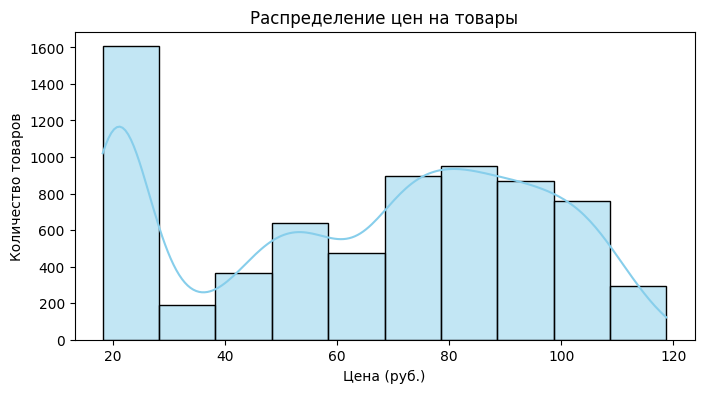

In [67]:
plt.figure(figsize=(8, 4))
sns.histplot(df['MonthlyCharges'], bins=10, kde=True, color='skyblue')
plt.title('Распределение цен на товары')
plt.xlabel('Цена (руб.)')
plt.ylabel('Количество товаров')
plt.show()


Ежемесячный платёж имеет две массы клиентов: бюджетный сегмент ( платёж около 20) и сегмент полного пакета ( платёж 70–100)

## 2. Ящик с усами
платёж по оттоку


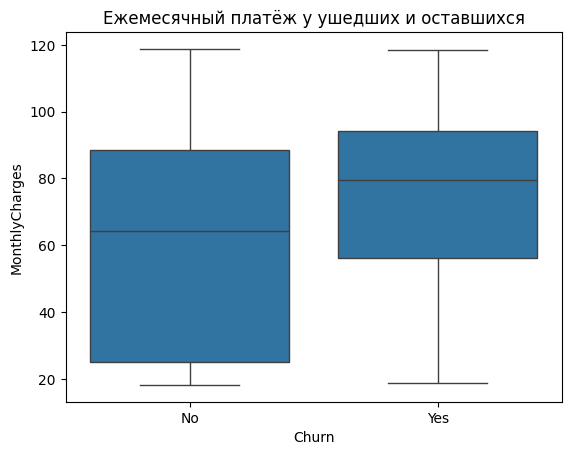

In [68]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Ежемесячный платёж у ушедших и оставшихся")
plt.show()

Исходя из графика: 
    медиана у No около 64
    медиана у Yes около 80
    весь ящик Yes сдвинут вверх
разброс похожий, отдельных  выбросов почти нет

Вывод: Ушедшие в среднем платят больше в месяц, чем оставшиеся. Отток связан не с дешёвым тарифом, а скорее с более дорогим ежемесячным счётом

## 3. Столбчатая диаграмма 

долю ушедших клиентов в каждом типе контракта

1) Month-to-month — платит каждый месяц, так как можно уйти почти сразу, то  отток самый высокий.
2) One year — контракт на год. Уйти дороже и сложнее, поэтому отток ниже.
3) Two year — контракт на два года. Самые надёжные клиенты,  поэтому отток минимальный.

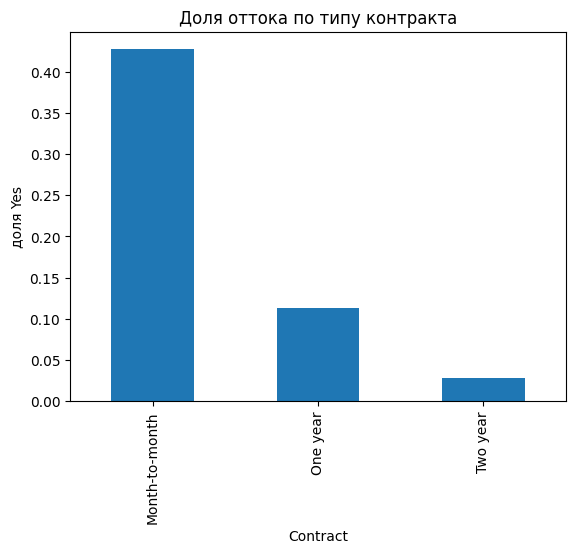

In [69]:
churn_by_contract = (
    df.assign(churn=(df["Churn"] == "Yes").astype(int))
      .groupby("Contract")["churn"].mean()
)
churn_by_contract.plot(kind="bar")
plt.title("Доля оттока по типу контракта")
plt.ylabel("доля Yes")
plt.show()

Вывод: Тип контракта — ключевой фактор риска.
Чем короче контракт, тем выше отток.
1) Month-to-month — около 43% уходят
2) One year — около 11%
3) Two year — около 3%

## Линейный график 
Доля оттока в зависимости от количества месяцев, в течение которых клиент пользуется услугами компании

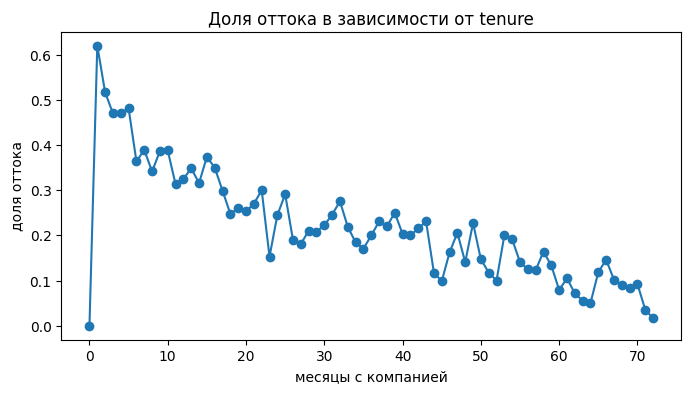

In [71]:
tmp = df.assign(churn=(df["Churn"] == "Yes").astype(int))
line = tmp.groupby("tenure")["churn"].mean()

plt.figure(figsize=(8, 4))
plt.plot(line.index, line.values, marker="o")
plt.title("Доля оттока в зависимости от tenure")
plt.xlabel("месяцы с компанией")
plt.ylabel("доля оттока")
plt.show()

Риск максимален в начале. Если клиент пережил первый год, вероятность ухода падает

Опасная зона — первые месяцы.